# **Understanding Depression Among Students: A Data-Driven Exploration**

In [1]:
student_name =   "Dharinisri Magudapathy Saravanakumar"
student_id =     "dhma0963"
student_background =  "health" # Describe background as [technical, health, design, etc.]

## **Data understanding**

**1**. Place the **source link** of the dataset you chose.[link text](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset)


**2**. What is the **domain area** of the dataset? Describe under which circumstances the data was collected and for which kind of task or purpose.

The dataset belongs to the domain of student mental health and educational psychology, designed to support research in psychology, education, and data science. While it is clearly aimed at analyzing and predicting depression levels among students, the specific circumstances of how the data was collected are not provided. No details about the data source, collection method, location, or participant demographics are explicitly mentioned.


**3**. What is the **data file structure**? Describe here how many files the dataset has, the file format, whether the data includes headers or additional metadata files. Also describe how the data values are separated (e.g., by commas, semicolon, tabs) and how many files you will need to load to access all features from the dataset.

**Number of files**: 1

**File format**: Student_depression_dataset.CSV

**Headers**: header row with column name are present

**Metadata**: Not provided

**Value separation**: Comma_Separated

**Number of files to be loaded**: 1 file (Student_depression_dataset.CSV) to access all features


**4**. How many **features** and how many **observations** does the dataset have?

**Features**: 18 (Columns)

**Observations**: 27,901(Rows)

**5**. Does it contain **numerical features**? Describe the quantity, labels, and if it does not contain numerical features, please find a different dataset where you can conduct numerical analysis.

Yes, the dataset has numerical features.
**Quantity**: 4

**Labels**:

Id -integer

Age-integer

CGPA-float   

work/study hour- integer

**6**. Does it contain **categorical features**? Describe how many, the labels, and whether they are ordinal or nominal.

Yes, the dataset has categorical features

**Quantity**: 8

**Labels**:

Gender-Nominal

City-Nominal

Academic satisfaction: Ordinal

Study satisfaction - Ordinal

Sleep duration - Ordinal

Dietary habits- Ordinal

Degree- Nominal

Financial stress - Ordinal

**7**. Does it contain **binary features**? Describe how many and list their labels. If it does not contain, briefly mention which relevant binary feature may be created/engineered based on the existing numerical or categorical features.

Yes , the dataset has binary features

**Quantity**:3

**Labels**:

Have you ever had suicidal thoughts?- yes/no

Family history of mental illness- yes/no

Depression- 0/1


# **Exploratory Data Analysis (EDA)**

**1.** Imported the Pandas library and loaded the dataset from a .csv file using the read_csv() function.

In [2]:
import pandas as pd
df = pd.read_csv("/student_depression_dataset.csv", true_values=["Yes"], false_values=["No"])
df.head()


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,True,3.0,1.0,False,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,False,3.0,2.0,True,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,False,9.0,1.0,True,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,True,4.0,5.0,True,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,True,1.0,1.0,False,0


## **Preprocessing pipeline**
**Create a Copy of the Original Dataset**

**2a**. A duplicate of the original DataFrame (df) has been created (df1) to preserve the integrity of the raw data. All modifications, transformations, and analyses will be performed on the copied version to ensure that the original dataset remains unchanged for reference.

In [3]:
df1 = df.copy()
df1.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,True,3.0,1.0,False,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,False,3.0,2.0,True,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,False,9.0,1.0,True,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,True,4.0,5.0,True,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,True,1.0,1.0,False,0


**Feature Selection**

**2b**. A few columns that were identified as irrelevant or not useful for analysis have been dropped from the dataset.The column **"Profession"** was removed because all entries indicated the same value — "Student". Since the dataset is explicitly focused on analyzing depression among students, this column provided no additional value or variability for analysis.The **id** column was removed because it serves only as a unique identifier and carries no analytical or predictive value.The **City** column was excluded due to its high cardinality and limited relevance in the context of analyzing mental health especially since the study's focus is not location-specific.
Additionally, **"Work Pressure"** and **"Job Satisfaction"** were dropped because they contained only a constant value (0) across all rows, offering no meaningful insight or variation.


In [4]:
df1.drop(columns= [col for col in ["id","City","Profession","Work Pressure","Job Satisfaction"]if col in df1.columns], inplace = True)
df1.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,True,3.0,1.0,False,1
1,Female,24.0,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,False,3.0,2.0,True,0
2,Male,31.0,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,False,9.0,1.0,True,0
3,Female,28.0,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,True,4.0,5.0,True,1
4,Female,25.0,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,True,1.0,1.0,False,0


**Rename Columns**

**2c.1**. The column originally named "Have you ever had suicidal thoughts?" has been renamed to "Suicidal Thoughts" for better readability and ease of reference during analysis. This shorter, clearer label helps streamline the dataset while preserving the original meaning of the question.



In [5]:
df1.rename(columns = {"Have you ever had suicidal thoughts ?": "Sucidal thoughts"}, inplace = True)

**2c.2.** Renaming the column Work/Study Hours to Study Hours is appropriate because all participants in the dataset are students. The term "Work" could be misleading, as it may imply part-time jobs or employment, which is not the focus here. Using "Study Hours" provides better clarity and aligns directly with the academic nature of the data.




In [6]:
df1.rename(columns={"Work/Study Hours": "Study Hours"}, inplace=True)


**Identify and Handle Missing Values**

**2d**. While preparing the dataset for a multivariate analysis to explore whether family history of mental illness and financial stress together increase the likelihood of depression, I identified an issue in the "Financial Stress" column, where an invalid value "?" was present.This caused errors during numerical operations and visualizations.Initially, these values were not recognized by df1.isnull().sum() because "?" is treated as a string, not as a standard missing value like NaN or None.  To resolve this, I cleaned the column by replacing the "?" with None, converted the values to numeric format, calculated the median of the valid entries, and filled any missing values with this median. This preprocessing step ensured that the data was consistent, accurate, and ready for further analysis.

In [7]:
df1["Financial Stress"] = df1["Financial Stress"].replace("?", None)
df1["Financial Stress"] = pd.to_numeric(df1["Financial Stress"])
median_value = df1["Financial Stress"].median()
df1["Financial Stress"] = df1["Financial Stress"].fillna(median_value)

In [8]:
(df1["Financial Stress"] == "?").sum()

np.int64(0)

**Assign Correct Data Types**

**2e**. The original dataset had integer data types for columns like Age, Academic Pressure, Study Satisfaction,Financial Stress and Work/Study Hours, but when loaded into Google Colab, they were auto-converted to float. To maintain semantic clarity, I converted these columns back to int using .astype(int). This is important because:

Academic Pressure and Study Satisfaction are ordinal categorical variables (e.g., ranked levels from 1 to 5), which should not be treated as continuous floats.

Age and Work/Study Hours are discrete numerical features and are more appropriately represented as integers.



In [9]:
df1["Age"] = df1["Age"].astype(int)
df1["Academic Pressure"] = df1["Academic Pressure"].astype(int)
df1["Study Satisfaction"] = df1["Study Satisfaction"].astype(int)
df1["Study Hours"] = df1["Study Hours"].astype(int)
df1["Financial Stress"] = df1["Financial Stress"].astype(int)


In [10]:
df1.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Sucidal thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,5,8.97,2,'5-6 hours',Healthy,B.Pharm,True,3,1,False,1
1,Female,24,2,5.90,5,'5-6 hours',Moderate,BSc,False,3,2,True,0
2,Male,31,3,7.03,5,'Less than 5 hours',Healthy,BA,False,9,1,True,0
3,Female,28,3,5.59,2,'7-8 hours',Moderate,BCA,True,4,5,True,1
4,Female,25,4,8.13,3,'5-6 hours',Moderate,M.Tech,True,1,1,False,0


**2f**:  The following code is used to check for missing (null) values in the dataset. This step helps identify incomplete entries that may need to be handled through imputation, removal, or further investigation during data cleaning.

In [11]:
df1.isnull().sum().sum()

np.int64(0)

## **Analytical Questions**

**3a**.What is the average study satisfaction among students who are  depressed? (**univariate with conditioning filtering**)

In [12]:
d = df1[df1["Depression"] == 1]
avg_sat = d["Study Satisfaction"]. mean()
avg_sat


np.float64(2.7514691478942215)



**Reflection:**  
The average study satisfaction score among students who are experiencing depression is approximately **2.75** (on what is likely a 1–5 scale). This suggests that students with depression tend to report relatively low levels of study satisfaction. It reflects a possible link between poor academic satisfaction and depressive symptoms.


**3b**. Among students with Unhealthy dietary habits, what is the distribution of their sleep duration?(**univariate with conditioning filtering**)

In [13]:
unhealthy_diet = df1[df1['Dietary Habits'] == 'Unhealthy']
sleep_distribution = unhealthy_diet['Sleep Duration'].value_counts()
print(sleep_distribution)


Sleep Duration
'Less than 5 hours'    3068
'7-8 hours'            2820
'More than 8 hours'    2241
'5-6 hours'            2180
Others                    8
Name: count, dtype: int64


**Reflection**: The data reveals that students with unhealthy dietary habits are more likely to sleep less than 5 hours, with over 3000 cases reported. This is a concerning trend, as poor diet and insufficient sleep can negatively impact mental health, cognitive performance, and overall well-being. Lifestyle interventions are clearly needed.

**4a**.How many students are there in each combination of sleep hours and depression status? **(bivariate,groupby)**

In [14]:
sleep_vs_depression = df1.groupby(["Sleep Duration", "Depression"]).size()
sleep_vs_depression


Sleep Duration       Depression
'5-6 hours'          0             2666
                     1             3517
'7-8 hours'          0             2975
                     1             4371
'Less than 5 hours'  0             2949
                     1             5361
'More than 8 hours'  0             2966
                     1             3078
Others               0                9
                     1                9
dtype: int64

**Reflection**:
The analysis shows that students across all sleep durations experience notable levels of depression. Interestingly, those sleeping less than 5 hours and also 7–8 hours show the highest number of depression cases (5361 and 4371, respectively). This suggests that both insufficient and average sleep may be associated with increased depression risk, highlighting the complexity of sleep's impact on mental health.


**4b**. What is the average academic pressure for each degree? **(bivariate, pivot table)**


In [15]:
pivot = df1.pivot_table(values="Academic Pressure", columns="Degree", aggfunc="mean")
pivot

Degree,'Class 12',B.Arch,B.Com,B.Ed,B.Pharm,B.Tech,BA,BBA,BCA,BE,...,MA,MBA,MBBS,MCA,MD,ME,MHM,MSc,Others,PhD
Academic Pressure,3.359375,3.063599,3.083001,3.118907,3.18642,3.078993,3.11,3.067529,3.126308,3.091354,...,3.066176,3.113879,3.155172,2.952107,3.071678,3.313514,2.937173,3.057143,2.942857,3.224138


**Reflection**:The pivot table reveals that Class 12 students face the highest academic pressure (3.36), followed by PhD students (3.22). This suggests that academic stress peaks during critical transition phases—before college and during advanced research degrees. The pivot table is effective for identifying such high-stress academic stages

## **Visualization**

**5a**. Does an increase in academic pressure correspond to a higher likelihood of students experiencing depression? (bivariate)

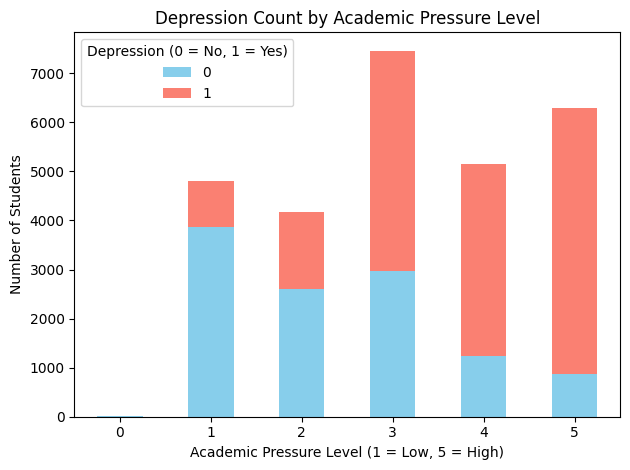

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

grouped = df1.groupby(['Academic Pressure', 'Depression']).size().unstack()

grouped.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])

plt.xlabel('Academic Pressure Level (1 = Low, 5 = High)')
plt.ylabel('Number of Students')
plt.title('Depression Count by Academic Pressure Level')
plt.legend(title='Depression (0 = No, 1 = Yes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Reflection:** The stacked bar chart shows a clear trend: as academic pressure increases, the number of students experiencing depression also rises. At higher pressure levels, the count of depressed students significantly outweighs non-depressed ones. This suggests a strong link between academic stress and depression, emphasizing the need for mental health support.The chart suggests a potential cause-effect relationship between academic pressure and depression, though it does not confirm causality.

**5b**. Is financial stress higher among students with suicidal thoughts compared to those without?

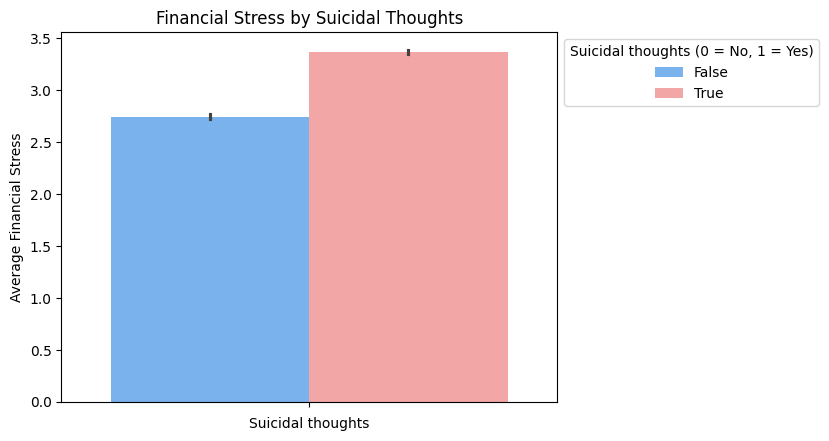

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(hue="Sucidal thoughts", y="Financial Stress", data=df1,palette={False: "#66B2FF",True: "#FF9999"})
plt.title("Financial Stress by Suicidal Thoughts")
plt.xlabel("Suicidal thoughts")
plt.ylabel("Average Financial Stress")
plt.legend(title='Suicidal thoughts (0 = No, 1 = Yes)', loc="upper left",bbox_to_anchor=(1, 1))
plt.show()


**Reflection**:This bar plot reveals that students who reported suicidal thoughts (True) exhibit a higher average financial stress level (3.4) compared to those who did not (False), whose average stress level is approximately 2.7.

This clear disparity suggests a strong association between financial stress and suicidal ideation. As financial stress increases, the likelihood of suicidal thoughts may also rise. The bar plot is an appropriate and effective visualization for this question, as it distinctly contrasts the average financial stress between the two groups making the potential relationship immediately apparent to the viewer.



**5c**. How does the distribution of depression differ between students with and without a family history of mental illness?



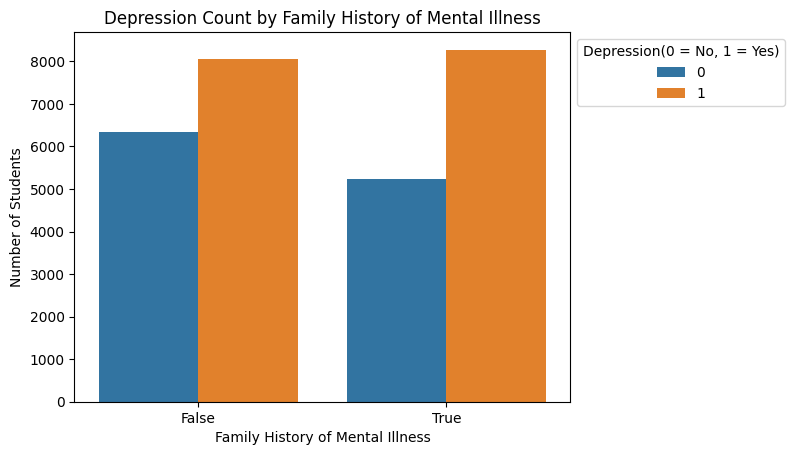

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Family History of Mental Illness", hue="Depression", data=df1)
plt.title("Depression Count by Family History of Mental Illness")
plt.xlabel("Family History of Mental Illness")
plt.ylabel("Number of Students")
plt.legend(title="Depression(0 = No, 1 = Yes)", loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


**Reflection**: The count plot shows that depression is common among students regardless of family history of mental illness. However, there is a slightly higher number of depressed students among those who reported a family history. While the difference is not very large, it still suggests that family mental health background could play a minor contributing role.

The chart is appropriate for this question, as it clearly visualizes and compares the distribution of depression across the two groups, helping to spot subtle differences in a straightforward way.



**5d**. How does the combination of  academic pressure, sleep duration, and maximum financial stress (level 5) impact depression levels among students?

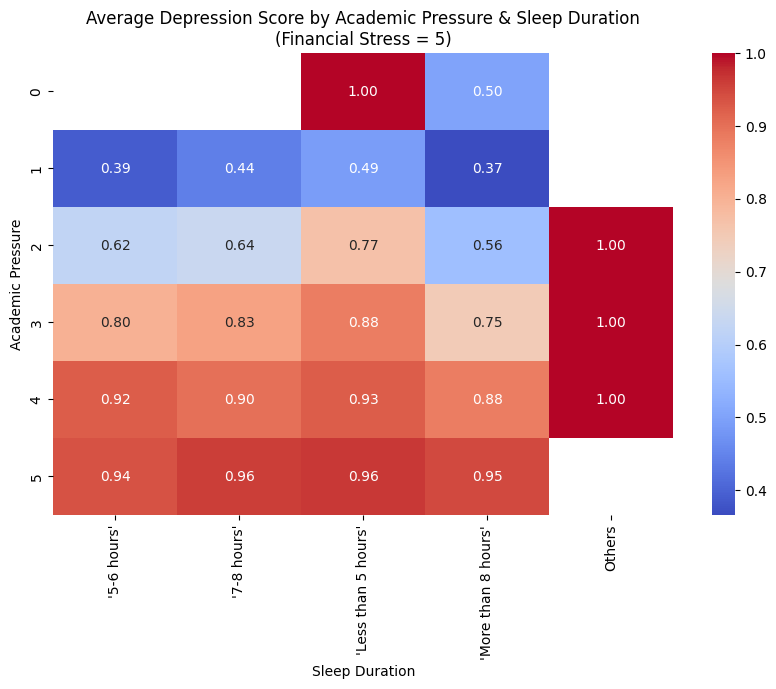

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

subset = df1[df1['Financial Stress'] == 5]

pivot_table = subset.pivot_table(values='Depression',
                                  index='Academic Pressure',
                                  columns='Sleep Duration',
                                  aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Average Depression Score by Academic Pressure & Sleep Duration\n(Financial Stress = 5)")
plt.ylabel("Academic Pressure")
plt.xlabel("Sleep Duration")
plt.show()


**Reflection:** The heatmap shows that under maximum financial stress, depression increases with rising academic pressure, regardless of sleep duration. Students sleeping less than 5 hours show higher depression, while even excessive sleep (over 8 hours) reflects elevated scores. The “Others” category records peak depression. Together, high academic pressure, poor sleep, and financial stress significantly raise depression risk in students.

The heatmap is effective for this multivariate question, as it allows quick comparison across three factors simultaneously, clearly highlighting patterns and intensities of depression.

## **Pearson correlation**

**6.** Is there a relationship between a student’s age and the number of hours they spend working or studying?

In [20]:
pearson_correlation = df1["Age"].corr(df1["Study Hours"], method = "pearson")
pearson_correlation

np.float64(-0.03292805879081237)

**Reflection**: The Pearson correlation between Age and Work/Study Hours is approximately -0.033, indicating a very weak negative correlation. This means that as age slightly increases,study hours tend to decrease marginally, though the relationship is too weak to be meaningful. Other variables likely influence study time more significantly.

In [21]:
df1.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Sucidal thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,5,8.97,2,'5-6 hours',Healthy,B.Pharm,True,3,1,False,1
1,Female,24,2,5.90,5,'5-6 hours',Moderate,BSc,False,3,2,True,0
2,Male,31,3,7.03,5,'Less than 5 hours',Healthy,BA,False,9,1,True,0
3,Female,28,3,5.59,2,'7-8 hours',Moderate,BCA,True,4,5,True,1
4,Female,25,4,8.13,3,'5-6 hours',Moderate,M.Tech,True,1,1,False,0


# **Homework 3**

## **1.Binary target class:**

I chose Depression as the binary target variable because it is already labeled as 0 (no) or 1 (yes), making it ideal for classification.

In [22]:
df1["Depression"].value_counts()



,count
Depression,
1,16336
0,11565


In [23]:
from sklearn.preprocessing import LabelEncoder
df1["Sucidal thoughts"] = df1["Sucidal thoughts"].astype(int)
df1["Family History of Mental Illness"] = df1["Family History of Mental Illness"].astype(int)
le_sleep = LabelEncoder()
df1["Sleep Duration"] = le_sleep.fit_transform(df1["Sleep Duration"])
df1[["Sucidal thoughts", "Family History of Mental Illness", "Sleep Duration"]]



,Sucidal thoughts,Family History of Mental Illness,Sleep Duration
0,1,0,0
1,0,1,0
2,0,1,2
3,1,1,1
4,1,0,0
...,...,...,...
27896,1,1,0
27897,0,1,2
27898,0,0,0
27899,1,0,2


**Reflection:**  The input features I selected—Sleep Duration, Suicidal Thoughts, and Family History of Mental Illness—are based on their strong clinical and psychological relevance to mental health outcomes. I applied Label Encoding to ordinal sleep categories and converted boolean values to integers for consistency. My prediction task is: I will build a model that predicts whether a person is depressed based on sleep habits, suicidal thoughts, and mental illness history.

###  **Converting DataFrame to NumPy Array**

To prepare the dataset for machine learning classification tasks, I selected three relevant features: Sucidal thoughts, Family History of Mental Illness, and Sleep Duration. These variables were encoded as integers, ensuring that the dataset was fully numerical. I then used the **.to_numpy()** method to convert the pandas DataFrame into a NumPy array, which is the expected format for most scikit-learn models. The resulting array has a shape of (27901, 3), confirming 27,901 observations with 3 features each, and a **dtype** of **int64**, proving that all values are numerical and ready for modeling. This step is crucial for ensuring compatibility with machine learning algorithms.


In [24]:
X = df1[["Sucidal thoughts", "Family History of Mental Illness", "Sleep Duration"]]
X_array = X.to_numpy()

print("X_array shape:", X_array.shape, "dtype:", X_array.dtype)


X_array shape: (27901, 3) dtype: int64


### **Plot a histogram for the target class**

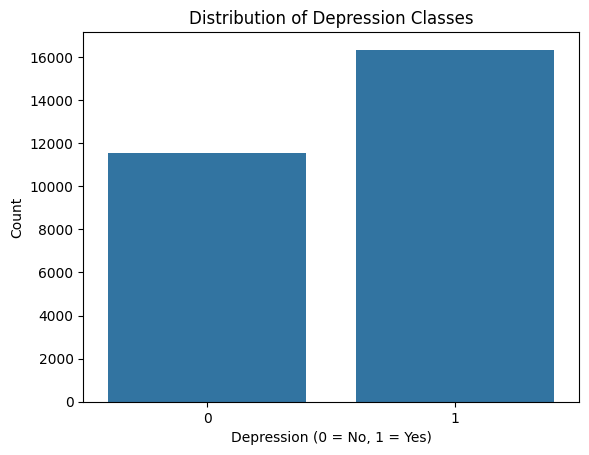

Depression
1    16336
0    11565
Name: count, dtype: int64


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt


# Plot a bar chart for the target class
sns.countplot(x="Depression", data=df1)
plt.title("Distribution of Depression Classes")
plt.xlabel("Depression (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
print(df1["Depression"].value_counts())


### **Calculating imbalance**

In [26]:
print(df1['Depression'].value_counts(normalize=True))


Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64


**Reflection**: The dataset shows mild class imbalance, with 58.5% of samples labeled as depressed and 41.4% of samples labeled as not depressed. While not extreme, this imbalance could bias machine learning models toward predicting depression more often, potentially reducing the model’s ability to correctly identify non-depressed individuals. Metrics like precision and recall should be closely monitored.


### **Separating features and target variables to x and y**

In [27]:
y = df1["Depression"]

X = df1[["Sucidal thoughts", "Family History of Mental Illness", "Sleep Duration"]]
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (27901, 3)
y shape: (27901,)


### **Stratified train-test partitioning :**  

Stratified train-test partitioning ensures class proportions in the target variable remain consistent across training and test sets. This is crucial for imbalanced datasets, as it prevents skewed model learning. In this case, it guarantees the depression classes (0 and 1) are equally represented, supporting fairer model evaluation and prediction accuracy.



In [28]:
from sklearn.model_selection import train_test_split

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=36
)

# Check shape of each set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))


X_train shape: (22320, 3)
X_test shape: (5581, 3)
y_train distribution:
 Depression
1    0.585484
0    0.414516
Name: proportion, dtype: float64
y_test distribution:
 Depression
1    0.585558
0    0.414442
Name: proportion, dtype: float64


**Reflection:**  The class distribution in both sets remains consistent (~58.5% for class 1, ~41.4% for class 0), which proves stratification is working.

# 4.**Evaluation:**

 create multiple classifier variants to compare how different algorithms and hyperparameter settings perform on the same task. This helps identify the most accurate and reliable model for our data.

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

classifiers = {
    'DT_depth3': DecisionTreeClassifier(max_depth=3, random_state=36),
    'DT_depth7': DecisionTreeClassifier(max_depth=7, random_state=36),

    'RF_10trees': RandomForestClassifier(n_estimators=10, random_state=36),
    'RF_100trees': RandomForestClassifier(n_estimators=100, random_state=36),

    'KNN_k3': KNeighborsClassifier(n_neighbors=3),
    'KNN_k7': KNeighborsClassifier(n_neighbors=7),

    'SVM_linear': SVC(kernel='linear', C=1),
    'SVM_rbf': SVC(kernel='rbf', C=1, gamma='scale'),

    'LR_l2': LogisticRegression(penalty='l2', C=1.0, solver='liblinear'),
    'LR_l1': LogisticRegression(penalty='l1', C=1.0, solver='liblinear')
}


**4.2. Experimental Evaluation** :

This code evaluates ten classifiers using cross-validation and test set metrics. It provides a comprehensive comparison of accuracy, precision, recall, and F1-score, helping identify the most effective model efficiently.


In [30]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import time

results = []

# Scoring metrics for cross-validation
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

for name, clf in classifiers.items():
    # 1. Measure training time (via cross-validation)
    start_train = time.time()
    scores = cross_validate(clf, X_train, y_train, scoring=scoring, cv=5, return_train_score=False)
    end_train = time.time()
    train_time = end_train - start_train

    # 2. Fit on full training set for prediction timing on unseen test set
    clf.fit(X_train, y_train)

    # 3. Measure prediction time on X_test
    start_pred = time.time()
    y_pred = clf.predict(X_test)
    end_pred = time.time()
    pred_time = end_pred - start_pred

    # 4. Evaluation on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # 5. Append all results
    results.append({
        'Classifier': name,
        'Train Time (s)': round(train_time, 4),
        'Prediction Time (s)': round(pred_time, 4),
        'CV Accuracy': round(np.mean(scores['test_accuracy']), 4),
        'CV Precision': round(np.mean(scores['test_precision']), 4),
        'CV Recall': round(np.mean(scores['test_recall']), 4),
        'CV F1-Score': round(np.mean(scores['test_f1']), 4),
        'Test Accuracy': round(acc, 4),
        'Test Precision': round(prec, 4),
        'Test Recall': round(rec, 4),
        'Test F1-Score': round(f1, 4)
    })

# Display results
results_df = pd.DataFrame(results).sort_values(by="CV F1-Score", ascending=False).reset_index(drop=True)
display(results_df)


,Classifier,Train Time (s),Prediction Time (s),CV Accuracy,CV Precision,CV Recall,CV F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,DT_depth3,0.2962,0.0147,0.7823,0.7891,0.8571,0.8217,0.7818,0.7961,0.8433,0.8190
1,DT_depth7,0.2142,0.0027,0.7823,0.7892,0.8571,0.8217,0.7814,0.7960,0.8427,0.8187
2,RF_10trees,0.9578,0.0080,0.7823,0.7892,0.8571,0.8217,0.7814,0.7960,0.8427,0.8187
3,RF_100trees,5.9466,0.0638,0.7823,0.7892,0.8571,0.8217,0.7814,0.7960,0.8427,0.8187
4,SVM_rbf,38.1134,2.6172,0.7823,0.7891,0.8571,0.8217,0.7818,0.7961,0.8433,0.8190
5,SVM_linear,21.7960,0.9998,0.7823,0.7891,0.8571,0.8217,0.7818,0.7961,0.8433,0.8190
6,LR_l2,0.1517,0.0015,0.7823,0.7891,0.8571,0.8217,0.7818,0.7961,0.8433,0.8190
7,LR_l1,0.1930,0.0015,0.7823,0.7891,0.8571,0.8217,0.7818,0.7961,0.8433,0.8190
8,KNN_k7,1.8514,0.3902,0.7609,0.7637,0.8681,0.8107,0.7818,0.7961,0.8433,0.8190
9,KNN_k3,4.4056,0.9861,0.7054,0.7281,0.8176,0.7649,0.7072,0.8004,0.6662,0.7271


**Reflection**: DT_depth3 seems to be the best model because it achieved the highest F1-score, tied with others, but had significantly lower training and prediction times, making it both accurate and efficient.

**4.3. Iterating on choices of hyperparameters and classifiers.**

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

# Define estimators and param grids
search_space = {
    'DT': {
        'model': DecisionTreeClassifier(random_state=36),
        'param_grid': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'criterion': ['gini', 'entropy']
        }
    },
    'RF': {
        'model': RandomForestClassifier(random_state=36),
        'param_grid': {
            'n_estimators': [10, 50],
            'max_depth': [5, 10, None]
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7, 9]
        }
    },
    'SVM': {
        'model': SVC(),
        'param_grid': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    },
    'LR': {
        'model': LogisticRegression(solver='liblinear'),
        'param_grid': {
            'penalty': ['l1', 'l2'],
            'C': [0.1, 1, 10]
        }
    }
}

# Run GridSearchCV for each model
results = []
best_models = {}

for name, config in search_space.items():
    print(f"\nRunning GridSearchCV for {name}...")
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['param_grid'],
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train, y_train)

    # Store results
    mean_cv_score = grid.best_score_
    results.append({
        'Model': name,
        'Best CV F1-Score': round(mean_cv_score, 4),
        'Best Params': grid.best_params_
    })
    best_models[name] = grid.best_estimator_

results_df = pd.DataFrame(results).sort_values(by='Best CV F1-Score', ascending=False).reset_index(drop=True)
print("\nGrid Search Summary:\n")
print(results_df)

best_model_name = results_df.iloc[0]['Model']
final_model = best_models[best_model_name]

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
print(f"\n Final Best Model: {best_model_name}")
print("\nTest Set Evaluation:\n")
print(classification_report(y_test, y_pred, digits=4))



Running GridSearchCV for DT...

Running GridSearchCV for RF...

Running GridSearchCV for KNN...

Running GridSearchCV for SVM...

Running GridSearchCV for LR...

Grid Search Summary:

  Model  Best CV F1-Score                                        Best Params
0    DT            0.8218  {'criterion': 'gini', 'max_depth': 5, 'min_sam...
1    RF            0.8217               {'max_depth': 5, 'n_estimators': 50}
2   SVM            0.8217   {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
3    LR            0.8217                        {'C': 0.1, 'penalty': 'l1'}
4   KNN            0.8131                                 {'n_neighbors': 9}

 Final Best Model: DT

Test Set Evaluation:

              precision    recall  f1-score   support

           0     0.7577    0.6948    0.7249      2313
           1     0.7960    0.8427    0.8187      3268

    accuracy                         0.7814      5581
   macro avg     0.7768    0.7687    0.7718      5581
weighted avg     0.7801    0.7814  

**Reflection**: I used GridSearchCV to automatically search for the best hyperparameter combinations for each classifier. It simplifies the tuning process by systematically evaluating all specified parameter options. To ensure fair and unbiased model evaluation, I used 5-fold cross-validation within GridSearchCV. This method splits the training data into five subsets: in each iteration, the model is trained on four folds and validated on the fifth. The process repeats five times, and the performance is averaged. This helps avoid overfitting and gives a more reliable estimate of how the model would perform on unseen data.



### **4.4.Analytical questions**
1. **Which classifier has the shortest average training time across 5-fold cross-validation?**

In [32]:
# Get training time from cross-validation
from sklearn.model_selection import cross_validate

train_times = {}
for name, clf in classifiers.items():
    start = time.time()
    cross_validate(clf, X_train, y_train, cv=5)
    end = time.time()
    train_times[name] = round(end - start, 4)

df_train_times = pd.DataFrame(train_times.items(), columns=["Classifier", "Training Time (s)"])
df_train_times = df_train_times.sort_values(by="Training Time (s)").reset_index(drop=True)

display(df_train_times)




,Classifier,Training Time (s)
0,DT_depth3,0.0472
1,DT_depth7,0.0489
2,LR_l2,0.1114
3,LR_l1,0.1352
4,RF_10trees,0.2506
5,KNN_k7,1.7812
6,KNN_k3,1.8511
7,RF_100trees,2.1834
8,SVM_linear,21.1910
9,SVM_rbf,38.2853


**Reflection:**  DT\_depth3 and DT\_depth7 had the shortest training times, making them computationally efficient. In contrast, SVM\_rbf took significantly longer, which may be unsuitable for time-sensitive or resource-limited environments.




**2**.**Which classifier maintains the best balance between precision and recall across all classes?**

In [33]:
from sklearn.metrics import f1_score

best_f1 = 0
best_model_f1 = ''

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')  # use macro for multiclass balance

    print(f"{name} F1-score: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_model_f1 = name

print(f"\n Best model balancing precision and recall: {best_model_f1} with F1-score: {best_f1:.4f}")


DT_depth3 F1-score: 0.7721
DT_depth7 F1-score: 0.7718
RF_10trees F1-score: 0.7718
RF_100trees F1-score: 0.7718
KNN_k3 F1-score: 0.7057
KNN_k7 F1-score: 0.7721
SVM_linear F1-score: 0.7721
SVM_rbf F1-score: 0.7721
LR_l2 F1-score: 0.7721
LR_l1 F1-score: 0.7721

 Best model balancing precision and recall: DT_depth3 with F1-score: 0.7721


**Reflection:**  The classifier that maintained the best balance between precision and recall across all classes was DT_depth3, with an F1-score of 0.7721. This indicates that the model performs consistently well in correctly identifying both positive and negative cases. Such balance is crucial in multiclass problems, where overfitting to one class can lead to poor generalization.

**3.** **Which model shows the least variance in F1-score across folds during cross-validation?**

In [34]:
from sklearn.model_selection import cross_val_score
import numpy as np

lowest_variance = float('inf')
most_stable_model = ''

for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_train, y_train, scoring='f1_macro', cv=5)
    variance = np.var(scores)
    print(f"{name} F1-score variance: {variance:.6f}")

    if variance < lowest_variance:
        lowest_variance = variance
        most_stable_model = name

print(f"\n Most consistent model across folds: {most_stable_model} with F1 variance: {lowest_variance:.6f}")


DT_depth3 F1-score variance: 0.000017
DT_depth7 F1-score variance: 0.000017
RF_10trees F1-score variance: 0.000017
RF_100trees F1-score variance: 0.000017
KNN_k3 F1-score variance: 0.005479
KNN_k7 F1-score variance: 0.003410
SVM_linear F1-score variance: 0.000017
SVM_rbf F1-score variance: 0.000017
LR_l2 F1-score variance: 0.000017
LR_l1 F1-score variance: 0.000017

 Most consistent model across folds: DT_depth7 with F1 variance: 0.000017




**Reflection**:  Multiple models had the same lowest F1-score variance, indicating equal consistency. The original code used only `<`, selecting the first match. Updating it to include `==` revealed all stable models.


**4.5.Which classification model seems to perform better in your data?  Would you deploy it in a real-life task? Why or why not?**

 While `DT_depth3` showed strong performance and fast training, making it suitable for real-time applications, standalone decision trees have limitations. They are prone to overfitting, sensitive to small data changes, and may underperform on complex or high-dimensional datasets. In real-world deployment, I would consider DTs only for simple, explainable tasks or use them within an ensemble method like Random Forest for better generalization.
